In [1]:
import polars as pl
import numpy as np
import joblib
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

In [4]:
train_df = pl.read_parquet("C:/CreditScoringMLE/ml_service/app/data/train_features.parquet")

feature_cols = [c for c in train_df.columns if c not in ("sk_id_curr", "target")]
X = train_df.select(feature_cols).to_pandas().copy()
y = train_df["target"].to_pandas().copy()

from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [5]:
model = joblib.load("C:/CreditScoringMLE/ml_service/app/models/xgboost_model.joblib")

val_proba = model.predict_proba(X_val)[:, 1]

prob_true, prob_pred = calibration_curve(y_val, val_proba, n_bins=10, strategy="quantile")

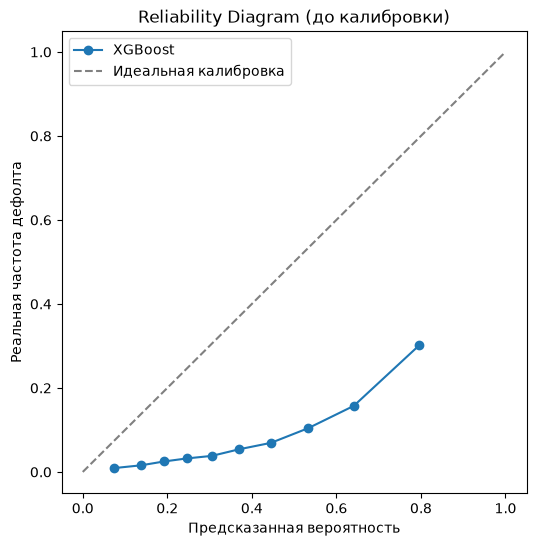

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(prob_pred, prob_true, marker="o", label="XGBoost")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Идеальная калибровка")
ax.set_xlabel("Предсказанная вероятность")
ax.set_ylabel("Реальная частота дефолта")
ax.set_title("Reliability Diagram (до калибровки)")
ax.legend()
plt.show()

In [7]:
from sklearn.metrics import brier_score_loss

brier_before = brier_score_loss(y_val, val_proba)
print(f"Brier Score (до калибровки): {brier_before:.4f}")

def expected_calibration_error(y_true, y_prob, n_bins=10):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (y_prob >= bin_edges[i]) & (y_prob < bin_edges[i + 1])
        if mask.sum() > 0:
            bin_acc = y_true[mask].mean()
            bin_conf = y_prob[mask].mean()
            ece += (mask.sum() / len(y_prob)) * abs(bin_acc - bin_conf)
    return ece

ece_before = expected_calibration_error(y_val.to_numpy(), val_proba)
print(f"ECE (до калибровки): {ece_before:.4f}")

Brier Score (до калибровки): 0.1731
ECE (до калибровки): 0.2935


In [8]:
print(f"Средний predict_proba: {val_proba.mean():.4f}")
print(f"Реальная доля дефолтов (y_val): {y_val.mean():.4f}")

Средний predict_proba: 0.3742
Реальная доля дефолтов (y_val): 0.0807


In [9]:
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split

# делим val на calib (для обучения калибратора) и test (для честной финальной проверки)
X_calib, X_test, y_calib, y_test = train_test_split(
    X_val, y_val, test_size=0.5, stratify=y_val, random_state=42
)

calib_proba_raw = model.predict_proba(X_calib)[:, 1]
test_proba_raw = model.predict_proba(X_test)[:, 1]

calibrator = IsotonicRegression(out_of_bounds="clip")
calibrator.fit(calib_proba_raw, y_calib)

test_proba_calibrated = calibrator.predict(test_proba_raw)

In [10]:
print(f"Средний predict_proba (до): {test_proba_raw.mean():.4f}")
print(f"Средний predict_proba (после): {test_proba_calibrated.mean():.4f}")
print(f"Реальная доля дефолтов: {y_test.mean():.4f}")

brier_after = brier_score_loss(y_test, test_proba_calibrated)
ece_after = expected_calibration_error(y_test.to_numpy(), test_proba_calibrated)
print(f"Brier Score (после): {brier_after:.4f}")
print(f"ECE (после): {ece_after:.4f}")

Средний predict_proba (до): 0.3738
Средний predict_proba (после): 0.0802
Реальная доля дефолтов: 0.0807
Brier Score (после): 0.0657
ECE (после): 0.0040


In [11]:
joblib.dump(calibrator, "C:/CreditScoringMLE/ml_service/app/models/calibrator.joblib")

['C:/CreditScoringMLE/ml_service/app/models/calibrator.joblib']

In [13]:
from sklearn.metrics import roc_auc_score

print(f"ROC-AUC до калибровки: {roc_auc_score(y_test, test_proba_raw):.4f}")
print(f"ROC-AUC после калибровки: {roc_auc_score(y_test, test_proba_calibrated):.4f}")

ROC-AUC до калибровки: 0.7892
ROC-AUC после калибровки: 0.7889
